# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
# from sklearn...
# import statsmodels.api as sm
# import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Load Data

In [12]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


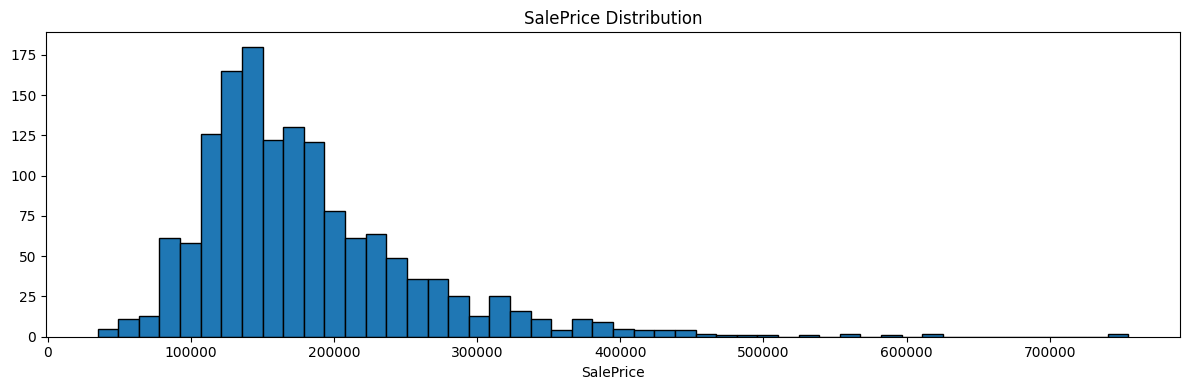

Skewness: 1.883


In [13]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

---
## Part 0: Cleanning data

In [14]:
nrow = len(train)
stats_list = []

for col in train.columns:
    n = train[col].isnull().sum()
    ratio_text = f"{n} / {nrow}"
    percentage = (n / nrow) * 100
    
    stats_list.append({
        'Colonne': col,
        'Format (n/nrow)': ratio_text,
        'Manquants (%)': round(percentage, 2)
    })

df_stats = pd.DataFrame(stats_list)

print("ÉTAT DES LIEUX DE TOUTES LES COLONNES :")
print(df_stats.sort_values(by='Manquants (%)', ascending=False).to_string(index=False))

for col in train.columns:
        # Si c'est du texte (Catégorique), on met "None"
        train[col] = train[col].fillna("None")

# --- VÉRIFICATION APRÈS ---
print("\n--- VÉRIFICATION APRÈS NETTOYAGE ---")
total_nans_restants = train.isnull().sum().sum()
print(f"Nombre total de cases vides dans tout le dataset : {total_nans_restants}")

ÉTAT DES LIEUX DE TOUTES LES COLONNES :
      Colonne Format (n/nrow)  Manquants (%)
       PoolQC     1453 / 1460          99.52
  MiscFeature     1406 / 1460          96.30
        Alley     1369 / 1460          93.77
        Fence     1179 / 1460          80.75
   MasVnrType      872 / 1460          59.73
  FireplaceQu      690 / 1460          47.26
  LotFrontage      259 / 1460          17.74
   GarageQual       81 / 1460           5.55
 GarageFinish       81 / 1460           5.55
   GarageType       81 / 1460           5.55
  GarageYrBlt       81 / 1460           5.55
   GarageCond       81 / 1460           5.55
 BsmtFinType2       38 / 1460           2.60
 BsmtExposure       38 / 1460           2.60
     BsmtCond       37 / 1460           2.53
     BsmtQual       37 / 1460           2.53
 BsmtFinType1       37 / 1460           2.53
   MasVnrArea        8 / 1460           0.55
   Electrical        1 / 1460           0.07
   Condition2        0 / 1460           0.00
     BldgType  

In [ ]:
# The following columns have a lot of missing values : PoolQC, MiscFeature, Alley, Fence, FireplaceQu. So those seem to be less significant for further analysis since we like data quite a lot of data for this feature. But for now, we change the missing values to "None" for all the colonum (categorical and numerical) to keep it simple. Also knowing that initialize to 0 for numerical columns can be inappropriate in some cases (For example in LotArea which can not logically have a base value of zero). We can always change the strategy later if we want to be more precise and also according to our needs.

- The following columns have a lot of missing values : PoolQC, MiscFeature, Alley, Fence and FireplaceQu. 
- So those seem to be less significant for further analysis since we lack quite a lot of data for this feature. But for now, we change the missing values to "None" for all the column (categorical and numerical) to keep it simple. 
- Also knowing that initialize to 0 for numerical columns can be inappropriate in some cases (For example in LotArea which can not logically have a base value of zero). 
- We can always change the strategy later if we want to be more precise and also according to our needs.

Comment : 
- As we can see, we have a 

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

In [78]:
#Descriptive statistics for the target variable
sp_mean = train['SalePrice'].mean()
sp_var = train['SalePrice'].var()
print(f'Mean: {sp_mean:,.2f} $, Variance: {sp_var:.3e}')
#add the skewness and kurtosis
print(f'Skewness: {train["SalePrice"].skew():.3f}')
print(f'Kurtosis: {train["SalePrice"].kurtosis():.3f}')

Mean: 180,921.20 $, Variance: 6.311e+09
Skewness: 1.883
Kurtosis: 6.536


#### Analysis of the numerical features

In [50]:
#Descriptive statistics for key features 
#key features are the ones that are most correlated with SalePrice, we can identify them using a their correlation with SalePrice
#We want the top features that are most positively and negatively correlated with SalePrice
####transform the non-numeric features to numeric and then calculate the correlation with SalePrice, then sort the values in descending order
correlations = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

#We can select the top 5 features that are most positive correlated with SalePrice
key_features = correlations[1:6].index
#we inverse the code for the negative correlation to have the most negative correlated features first
#key_features_ne = correlations[-4:-1].index
#print('Correlation of features with SalePrice:')
for feature in correlations.index:
    print(f'- {feature} : {correlations[feature]:.3f}')
print("-"*50)
print('Key features most correlated with SalePrice (They are all positive actually):')
for feature in key_features:
    print(f'- {feature} : {correlations[feature]:.3f}')



- SalePrice : 1.000
- OverallQual : 0.791
- GrLivArea : 0.709
- GarageCars : 0.640
- GarageArea : 0.623
- TotalBsmtSF : 0.614
- 1stFlrSF : 0.606
- FullBath : 0.561
- TotRmsAbvGrd : 0.534
- YearBuilt : 0.523
- YearRemodAdd : 0.507
- GarageYrBlt : 0.486
- MasVnrArea : 0.477
- Fireplaces : 0.467
- BsmtFinSF1 : 0.386
- LotFrontage : 0.352
- WoodDeckSF : 0.324
- 2ndFlrSF : 0.319
- OpenPorchSF : 0.316
- HalfBath : 0.284
- LotArea : 0.264
- BsmtFullBath : 0.227
- BsmtUnfSF : 0.214
- BedroomAbvGr : 0.168
- ScreenPorch : 0.111
- PoolArea : 0.092
- MoSold : 0.046
- 3SsnPorch : 0.045
- BsmtFinSF2 : -0.011
- BsmtHalfBath : -0.017
- MiscVal : -0.021
- Id : -0.022
- LowQualFinSF : -0.026
- YrSold : -0.029
- OverallCond : -0.078
- MSSubClass : -0.084
- EnclosedPorch : -0.129
- KitchenAbvGr : -0.136
--------------------------------------------------
Key features most correlated with SalePrice (They are all positive actually):
- OverallQual : 0.791
- GrLivArea : 0.709
- GarageCars : 0.640
- GarageArea 

Commentary on the correlation results:
- The most positively correlated features with SalePrice are OverallQual, GrLivArea, GarageCars, GarageArea and TotalBsmtSF. This makes sense since **these features are related to the quality** and **size of the house**, which are important factors in determining its price.
- There are **no features that are strongly negatively** correlated with SalePrice, which suggests that there are no features in the database which will strongly negativily affect the SalePrince
- Maybe it could be interresting to add other **variable from others categories** even if the are not in the top but also that **are not by first hand numerical**


In [49]:
#We include the target variable in the top features list to have a better visualization of the correlation between the features and the target variable
top_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

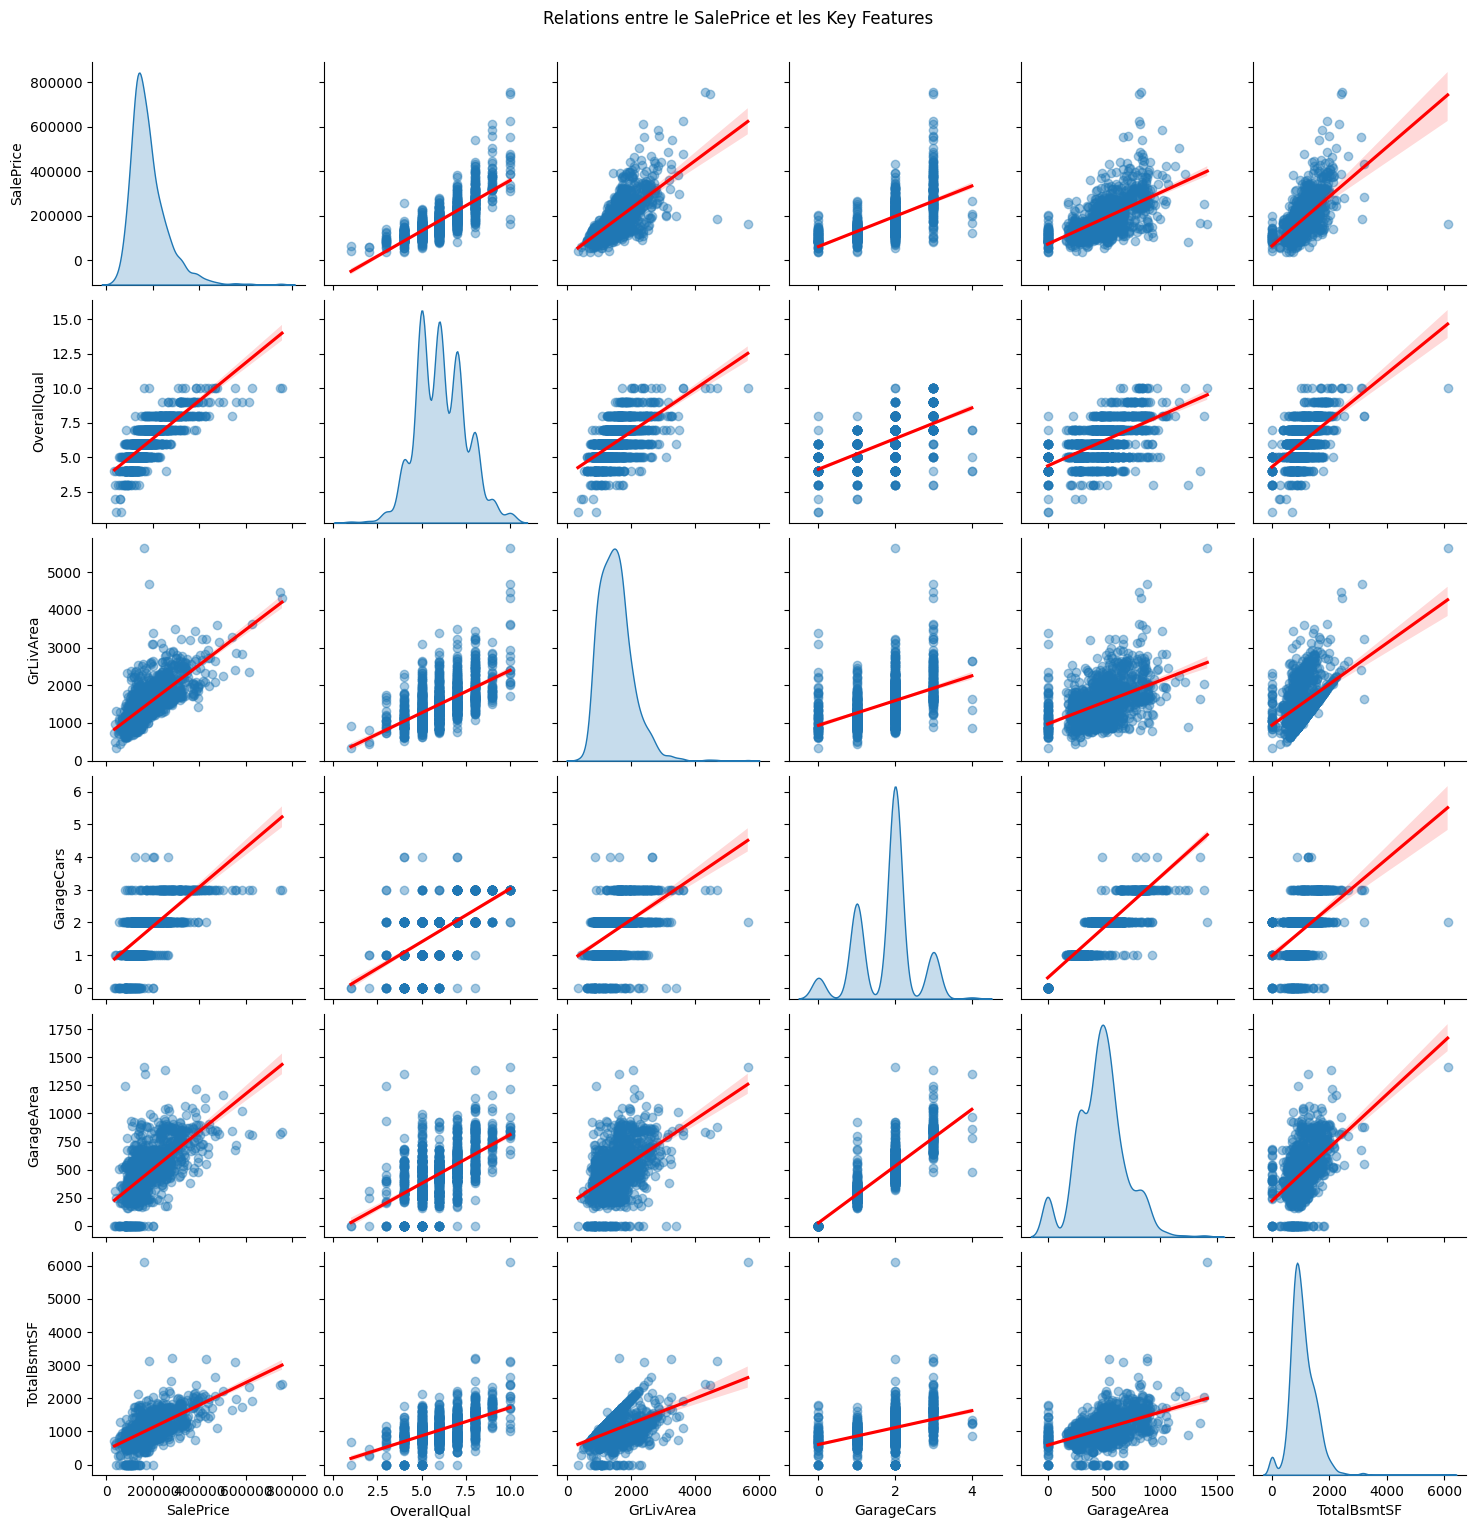

In [51]:
#We can also visualize the correlation between SalePrice and the key features using scatter plots
# Creation of Pairplot which shows the relationships between the key features and SalePrice with scatter points and regression lines
# 'kind="reg"' ajoute une ligne de régression pour mieux voir la tendance
# 'diag_kind="kde"' rend les histogrammes de la diagonale plus lisses
sns.pairplot(train[top_features], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.4}})

plt.suptitle("Relations entre le SalePrice et les Key Features", y=1.02)
plt.show()

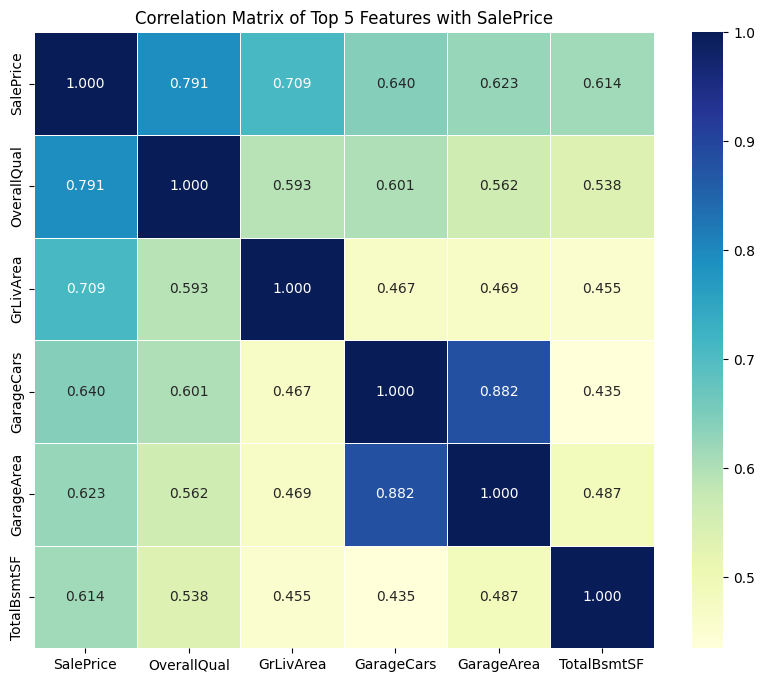

In [ ]:
# 2. Calcul de la corrélation
top_corr = train[top_features].corr()

# 3. Affichage de la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=0.5)

plt.title("Correlation Matrix of Top 5 Features with SalePrice")
plt.show()

Commentary on the correlation matrix:
- GarageCars and GarageArea are highly correlated with each other (0.88), which makes sense since they both measure the size of the garage. If a garage is big, it can contains more cars. So we could consider keeping only one of them in our model to avoid multicollinearity issues.
- We could use the others 3 features which are not strongly correlated


In [ ]:
#general descriptive statistics for the key features
stats_summary = train[key_features].agg(['mean', 'var', 'std']).T

# On renomme les colonnes pour que ce soit propre
stats_summary.columns = ['Moyenne', 'Variance', 'Écart-type']
print(stats_summary)

                 Moyenne       Variance  Écart-type
OverallQual     6.099315       1.912679    1.382997
GrLivArea    1515.463699  276129.633363  525.480383
GarageCars      1.767123       0.558480    0.747315
GarageArea    472.980137   45712.510229  213.804841
TotalBsmtSF  1057.429452  192462.361709  438.705324


Commentary
- `OverallQual` : La qualité moyenne se situe à 6,1/10, indiquant un parc immobilier globalement "Au-dessus de la moyenne" avec une dispersion assez faible ($s = 1,38$).
- `GrLivArea` : La surface habitable moyenne est de 1 515 sq ft, mais l'écart-type élevé de 525 montre une grande diversité de tailles, allant de petits bungalows à de vastes propriétés
- `GarageCars` : Avec une moyenne de 1,77, le garage pour deux voitures est la norme standard pour la majorité des habitations de ce dataset.
- `GarageArea` : La surface moyenne des garages est de 473 sq ft, une mesure très hétérogène qui reflète les différences de conception entre garages simples et doubles.
- `TotalBsmtSF` : Le sous-sol affiche une moyenne de 1 057 sq ft, mais sa variance massive signale que cette caractéristique est l'une des plus variables selon le type de construction.

---

#### Analysis of the non-numerical features

---

In [58]:


#confidence interval for mean at 95% confidence level (alpha = 0.05)
alpha = 0.05
n = len(train['SalePrice'])
sd = np.sqrt(sp_var / n)
z_score = stats.norm.ppf(1 - alpha/2)
margin_error = z_score * sd
lower_bound = sp_mean - margin_error
upper_bound = sp_mean + margin_error
print(f'Confidence Interval: ({lower_bound:,.2f}, {upper_bound:,.2f})')
#print(f'Conclusion: We are 95% confident that the true mean SalePrice lies between {lower_bound:,.2f} and {upper_bound:,.2f}.')

Confidence Interval: (176,846.22, 184,996.17)


Conclusion: 
- We are 95% confident that the true mean SalePrice lies between 176,846.22\$ and 184,996.17\$

In [62]:
# Hypothesis testing for the mean SalePrice
# H0: The mean SalePrice is equal to a certain value (we will use $180,000)
# H1: The mean SalePrice is not equal to that value

# Define the null hypothesis value
null_mean = 180000

# Execution of the t-test
t_stat, p_value = stats.ttest_1samp(train['SalePrice'], null_mean, alternative='two-sided')

print(f"Statistique T : {t_stat:.4f}")
print(f"P-value : {p_value:.4e}") 

Statistique T : 0.4431
P-value : 6.5778e-01


Conclusion :
- Since the p-value (0.658) > 0.05, the statistical decision is clear: We cannot reject the null hypothesis (H0).
- Conclusion: The mean SalePrice is not significantly different from $180,000.

In [63]:
#Proof of non-normality of the target variable using the Shapiro-Wilk test
#H0: The SalePrice variable is normally distributed (if p-value > 0.05, we fail to reject H0)
#H1: The SalePrice variable is not normally distributed

shapiro_stat, shapiro_p = stats.shapiro(train['SalePrice'])

print(f"P-value Shapiro-Wilk : {shapiro_p:.4e}")

P-value Shapiro-Wilk : 3.2061e-33


Comment : 
- The p-value for the Shapiro-Wilk test is very small (less than 0.05), we reject the null hypothesis and conclude that the SalePrice variable is not normally distributed.
- This conclusion is consistent with the skewness value we saw on the histogram of SalePrice, which was 1.88, indicating a strong positive skewness.
- Thus, we will apply a log transformation to the SalePrice variable to make it more normally distributed for our tests and future modeling. 
- This is necessary because many statistical models assume that the target variable is normally distributed, and a log transformation can help to reduce skewness and make the distribution more symmetric.

In [ ]:
#Proof of normality of the transformed target variable using the Shapiro-Wilk test
#H0: The log-transformed SalePrice variable is normally distributed (if p-value > 0.05, we fail to reject H0)
#H1: The log-transformed SalePrice variable is not normally distributed

#We create a new column for the log-transformed SalePrice
train['LogSalePrice'] = np.log(train['SalePrice'])
# La bonne façon de transformer
#train['Log_SalePrice'] = np.log1p(train['SalePrice'])

#Perform the Shapiro-Wilk test on the log-transformed variable
shapiro_stat, shapiro_p = stats.shapiro(train['LogSalePrice'])

print(f"P-value Shapiro-Wilk (LogSalePrice): {shapiro_p:.4e}")

P-value Shapiro-Wilk (LogSalePrice): 1.1491e-07


Comment :
- Even with the log transformation, the p-value is still very small (less than 0.05), we reject the null hypothesis and conclude that the LogSalePrice variable is not normally distributed. This suggests that the log transformation did not fully normalize the distribution of SalePrice, and there may still be some skewness or outliers present in the data.
- Shoud we continue on just visualize the Q-Q plot to find that is transformation is quite normal especially compare to the SalePrice ?
- Or should we remove the outliers and redo the test ? 


In [67]:
# 1. On travaille sur les données en log (puisqu'on veut normaliser le log)
data_log = np.log1p(train['SalePrice'])

# 2. Calcul des quartiles (Q1, Q3) et de l'IQR
Q1 = data_log.quantile(0.25)
Q3 = data_log.quantile(0.75)
IQR = Q3 - Q1

# 3. Définition des bornes (1.5 * IQR est le standard)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filtrage des données (on ne garde que ce qui est "dedans")
# ~ est l'opérateur de négation (on garde ce qui n'est PAS un outlier)
outliers_mask = (data_log < lower_bound) | (data_log > upper_bound)
data_clean_log = data_log[~outliers_mask]

print(f"Nombre de lignes avant : {len(data_log)}")
print(f"Nombre de lignes après : {len(data_clean_log)}")
print(f"Nombre d'outliers supprimés : {len(data_log) - len(data_clean_log)}")

# 5. Nouveau test de Shapiro-Wilk sur les données nettoyées
stat, p_clean = stats.shapiro(data_clean_log)
print(f"Nouvelle P-value Shapiro-Wilk (nettoyée) : {p_clean:.4e}")

Nombre de lignes avant : 1460
Nombre de lignes après : 1432
Nombre d'outliers supprimés : 28
Nouvelle P-value Shapiro-Wilk (nettoyée) : 3.6299e-06


- Even although we removed the outliers, the p-value is still very small (less than 0.05). It is possible because the shapiro-wilk test is very sensitive to large sample sizes, and even a small deviation from normality can lead to a rejection of the null hypothesis. 
- We can also visualize the QQ plot of the SalePrice and the log-transformed SalePrice to see the difference in normality. The QQ plot of the log-transformed SalePrice should show points that are closer to the diagonal line, indicating a better fit to a normal distribution, compared to the QQ plot of the original SalePrice. 

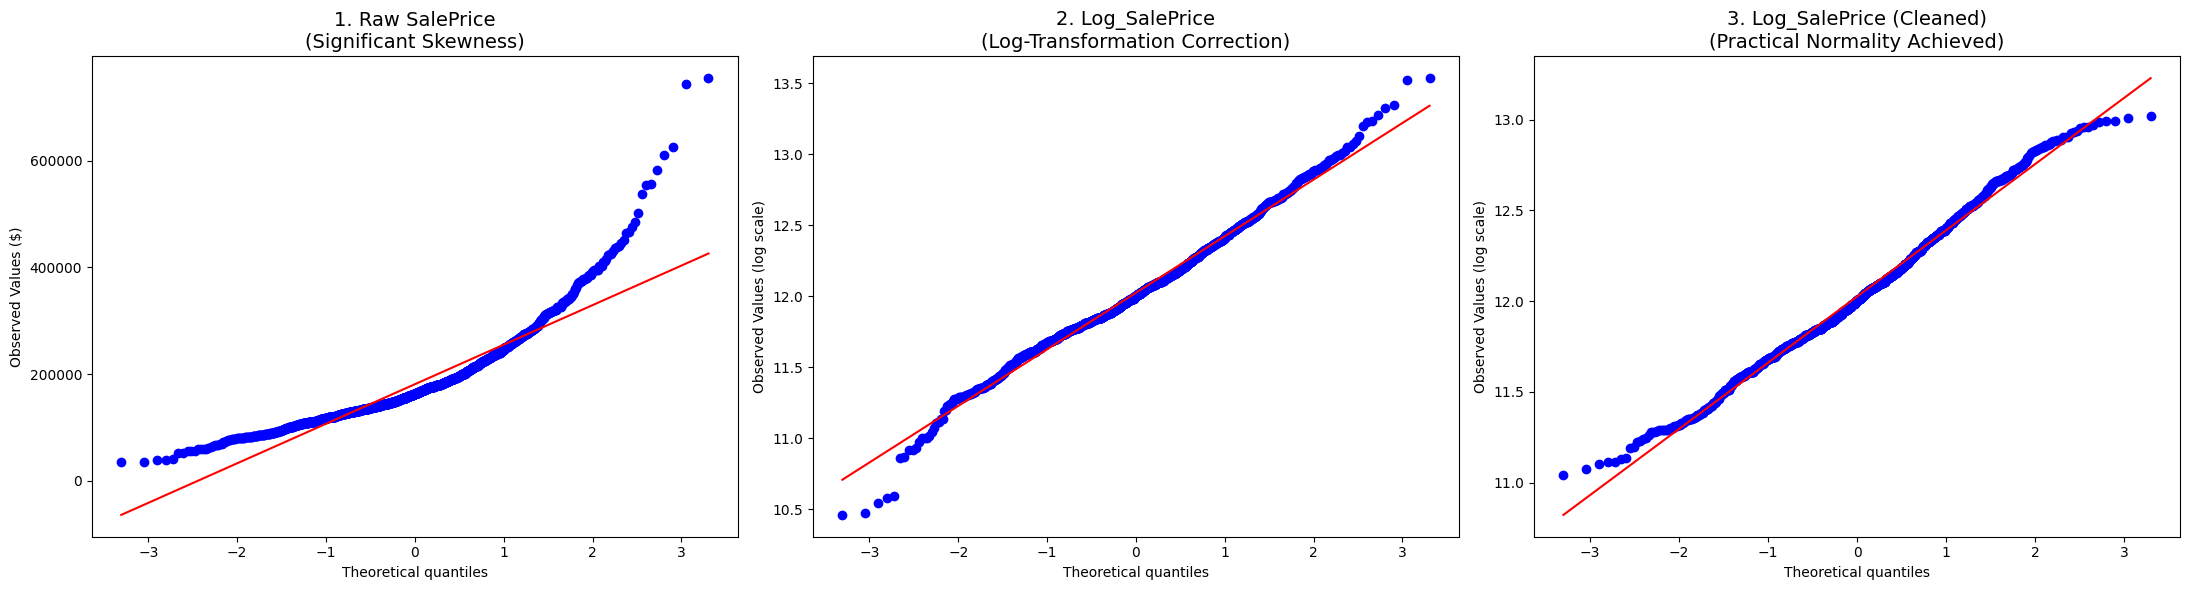

In [ ]:
# Prepare the three versions of the target variable
y_raw = train['SalePrice']
y_log = np.log1p(train['SalePrice'])

# Calculate and remove outliers on the Log version (IQR Method)
Q1 = y_log.quantile(0.25)
Q3 = y_log.quantile(0.75)
IQR = Q3 - Q1
# Filtering: keeping only data within 1.5 * IQR
y_log_no_outliers = y_log[~((y_log < (Q1 - 1.5 * IQR)) | (y_log > (Q3 + 1.5 * IQR)))]

# 2. Create the figure (1 row, 3 columns)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot 1: Raw Data ---
stats.probplot(y_raw, dist="norm", plot=ax1)
ax1.set_title("1. Raw SalePrice\n(Significant Skewness)", fontsize=14)
ax1.set_ylabel("Observed Values ($)")

# --- Plot 2: Log Transformed ---
stats.probplot(y_log, dist="norm", plot=ax2)
ax2.set_title("2. Log_SalePrice\n(Log-Transformation Correction)", fontsize=14)
ax2.set_ylabel("Observed Values (log scale)")

# --- Plot 3: Log + No Outliers ---
stats.probplot(y_log_no_outliers, dist="norm", plot=ax3)
ax3.set_title("3. Log_SalePrice (Cleaned)\n(Practical Normality Achieved)", fontsize=14)
ax3.set_ylabel("Observed Values (log scale)")

plt.tight_layout()
plt.show()

Comment : 
- We can see that the Log_SalePrince the really closer to the qunatile of the normal distribution. This show us that this tranformation is really useful and significant in order to have a almost normal distribution to apply futher test and modelling.
- However, we can see that the different between the Log_SalePrice witch and Without outliers is small so we may keep them for the following analysis

In [75]:
#We may now want to describe Log_SalePrice variable using descriptive statistics
print(y_log.describe())
#add the variance, skewness and kurtosis
print(f'Variance: {y_log.var():.3e}')
print(f'Skewness: {y_log.skew():.3f}')
print(f'Kurtosis: {y_log.kurtosis():.3f}')

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64
Variance: 1.596e-01
Skewness: 0.121
Kurtosis: 0.810


- We went from a skewness of 1.88 for the raw SalePrice to a skewness of 0.12 and a kurtosis of 6.54 to 0.8, which is much closer to the skewness of 0 and kurtosis of 3 for a normal distribution.
- This indicates that the log transformation has significantly improved the normality of the SalePrice variable, making it more suitable for modeling techniques that assume normality.

In [ ]:
# We can also visualize the distribution of the log-transformed SalePrice variable using a histogram and a boxplot

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Summarize: which features and interactions are significant?

In [ ]:
#is it relevant to show the element use to make the ANOVA test ? 
#Maybe it can help to understand the results of the ANOVA test and also we coud interpret those elements for futher analysis 

In [ ]:
import pingouin as pg

# C'est aussi simple que ça :
# dv = variable dépendante (le prix)
# between = les deux facteurs à tester
aov = pg.anova(dv='SalePrice_log', between=['Neighborhood', 'ExterQual'], data=df_anova)

print(aov)

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.

---
# Execution

### Part 1

In [ ]:
sp_mean = train['SalePrice'].mean()
sp_var = train['SalePrice'].var()
print(f'Mean: {sp_mean:.2f}, Variance: {sp_var:.2f}')

#confidence interval for mean at 95% confidence level (alpha = 0.05)
alpha = 0.05
n = len(train['SalePrice'])
sd = np.sqrt(sp_var / n)
z_score = stats.norm.ppf(1 - alpha/2)
margin_error = z_score * sd
lower_bound = sp_mean - margin_error
upper_bound = sp_mean + margin_error
print(f'Confidence Interval: ({lower_bound:.2f}, {upper_bound:.2f})')

NameError: name 'train' is not defined

---
### Hypothesis test 

We will test if the average sale is ..
**For this, we define** 

-Ho : 

-H1 : 


In [ ]:
#hypothesis testing: H0: mean = 180000, H1: mean != 180000
hyp_mean = 180000
